# 6CS012 - Worksheet 1
## Image Compression and Decompression using PCA
---

## Setup - Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

print('All libraries imported successfully!')


All libraries imported successfully!


## Download Sample Images

In [3]:
from google.colab import drive
drive.mount('/content/drive')

colour_image_path = '/content/drive/MyDrive/AI and Machine Learning/Image.jpg'
gray_image_path   = '/content/drive/MyDrive/AI and Machine Learning/Image.jpg'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
# Exercise 1 - Working with a Colour (RGB) Image

### Task 1: Read and Display the Image

Image shape: (360, 735, 3)
Image dtype: uint8


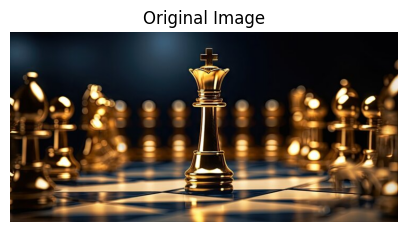

In [5]:
img_pil = Image.open('/content/drive/MyDrive/AI and Machine Learning/Image.jpg')

img = np.array(img_pil)

print('Image shape:', img.shape)
print('Image dtype:', img.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()


### Task 2: Display Top-Left Corner (100x100 pixels)

Cropped image shape: (100, 100, 3)


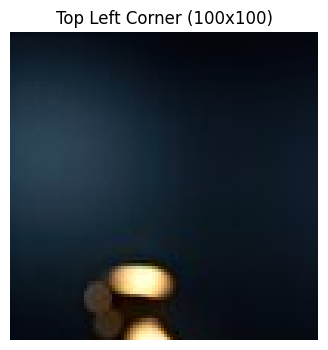

In [6]:
top_left = img[0:100, 0:100]

print('Cropped image shape:', top_left.shape)

plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title('Top Left Corner (100x100)')
plt.axis('off')
plt.show()


### Task 3: Show the Three Colour Channels (R, G, B)

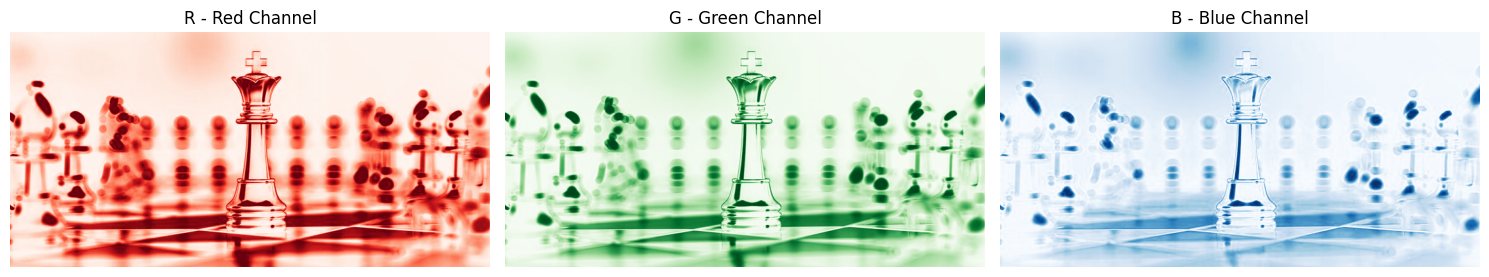

In [7]:
red_channel   = img[:, :, 0]
green_channel = img[:, :, 1]
blue_channel  = img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title('R - Red Channel')
axes[0].axis('off')

axes[1].imshow(green_channel, cmap='Greens')
axes[1].set_title('G - Green Channel')
axes[1].axis('off')

axes[2].imshow(blue_channel, cmap='Blues')
axes[2].set_title('B - Blue Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### Task 4: Modify Top 100x100 Pixels to Value 210

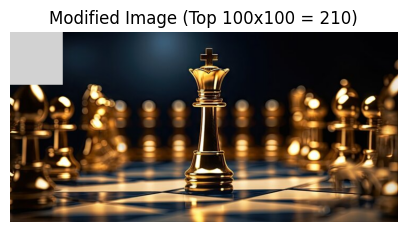

Top-left pixel value: [210 210 210]


In [8]:
img_modified = img.copy()

img_modified[0:100, 0:100] = 210

plt.figure(figsize=(5, 5))
plt.imshow(img_modified)
plt.title('Modified Image (Top 100x100 = 210)')
plt.axis('off')
plt.show()

print('Top-left pixel value:', img_modified[0, 0])


### Exercise 1 - All Tasks Summary Plot

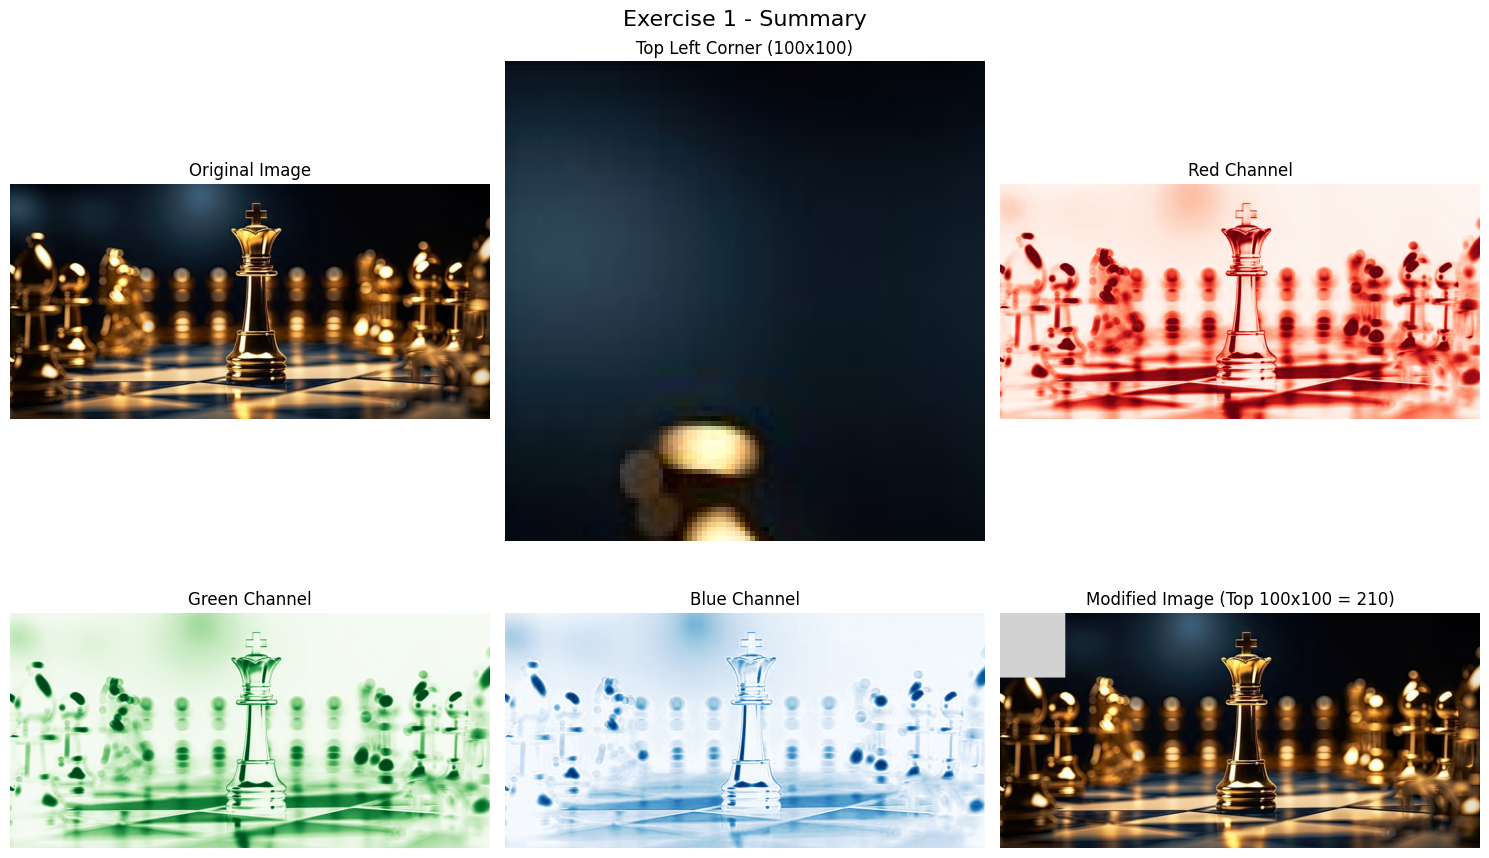

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(top_left)
axes[0, 1].set_title('Top Left Corner (100x100)')
axes[0, 1].axis('off')

axes[0, 2].imshow(red_channel, cmap='Reds')
axes[0, 2].set_title('Red Channel')
axes[0, 2].axis('off')

axes[1, 0].imshow(green_channel, cmap='Greens')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(blue_channel, cmap='Blues')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_modified)
axes[1, 2].set_title('Modified Image (Top 100x100 = 210)')
axes[1, 2].axis('off')

plt.suptitle('Exercise 1 - Summary', fontsize=16)
plt.tight_layout()
plt.show()


---
# Exercise 2 - Working with a Grayscale Image

### Task 1: Load and Display a Grayscale Image

Grayscale image shape: (360, 735)
Pixel value range: 0 to 255


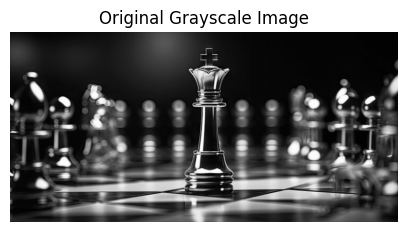

In [11]:
gray_pil = Image.open('/content/drive/MyDrive/AI and Machine Learning/Image.jpg').convert('L')
gray_img = np.array(gray_pil)

print('Grayscale image shape:', gray_img.shape)
print('Pixel value range:', gray_img.min(), 'to', gray_img.max())

plt.figure(figsize=(5, 5))
plt.imshow(gray_img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()


### Task 2: Extract Middle Section (150x150 pixels)

Image size: 360 x 735
Center point: row=180, col=367
Middle section shape: (150, 150)


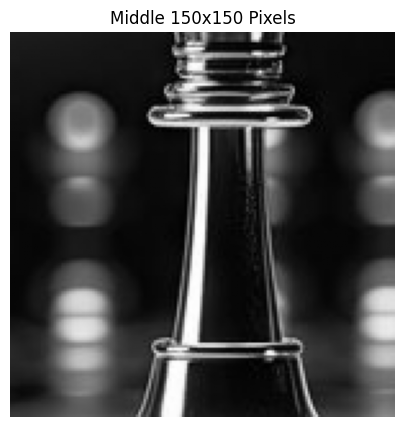

In [12]:
h, w = gray_img.shape
center_row = h // 2
center_col = w // 2

print(f'Image size: {h} x {w}')
print(f'Center point: row={center_row}, col={center_col}')

half = 75
middle_section = gray_img[center_row - half : center_row + half,
                           center_col - half : center_col + half]

print('Middle section shape:', middle_section.shape)

plt.figure(figsize=(5, 5))
plt.imshow(middle_section, cmap='gray')
plt.title('Middle 150x150 Pixels')
plt.axis('off')
plt.show()


### Task 3: Apply Threshold (below 100 → 0, above 100 → 255)

Unique values after threshold: [  0 255]


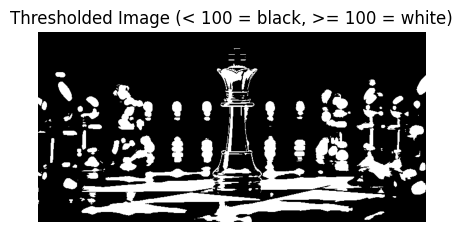

In [13]:
thresholded = gray_img.copy()

thresholded[gray_img < 100]  = 0
thresholded[gray_img >= 100] = 255

print('Unique values after threshold:', np.unique(thresholded))

plt.figure(figsize=(5, 5))
plt.imshow(thresholded, cmap='gray')
plt.title('Thresholded Image (< 100 = black, >= 100 = white)')
plt.axis('off')
plt.show()


### Task 4: Rotate Image 90 Degrees Clockwise

Original shape: (360, 735)
Rotated shape:  (360, 735)


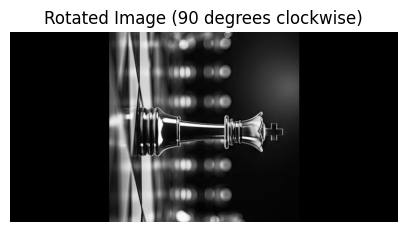

In [14]:
rotated_pil = gray_pil.rotate(-90)
rotated_img = np.array(rotated_pil)

print('Original shape:', gray_img.shape)
print('Rotated shape: ', rotated_img.shape)

plt.figure(figsize=(5, 5))
plt.imshow(rotated_img, cmap='gray')
plt.title('Rotated Image (90 degrees clockwise)')
plt.axis('off')
plt.show()


### Task 5: Convert Grayscale to RGB

Grayscale shape: (360, 735)
RGB image shape: (360, 735, 3)


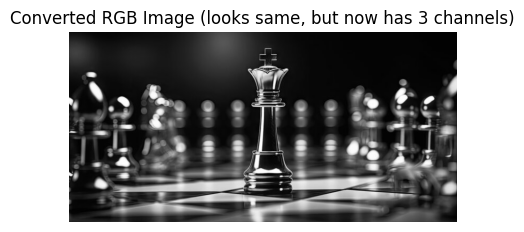

In [15]:
rgb_from_gray = np.stack([gray_img, gray_img, gray_img], axis=2)

print('Grayscale shape:', gray_img.shape)
print('RGB image shape:', rgb_from_gray.shape)

plt.figure(figsize=(5, 5))
plt.imshow(rgb_from_gray)
plt.title('Converted RGB Image (looks same, but now has 3 channels)')
plt.axis('off')
plt.show()


### Exercise 2 - All Tasks Summary Plot

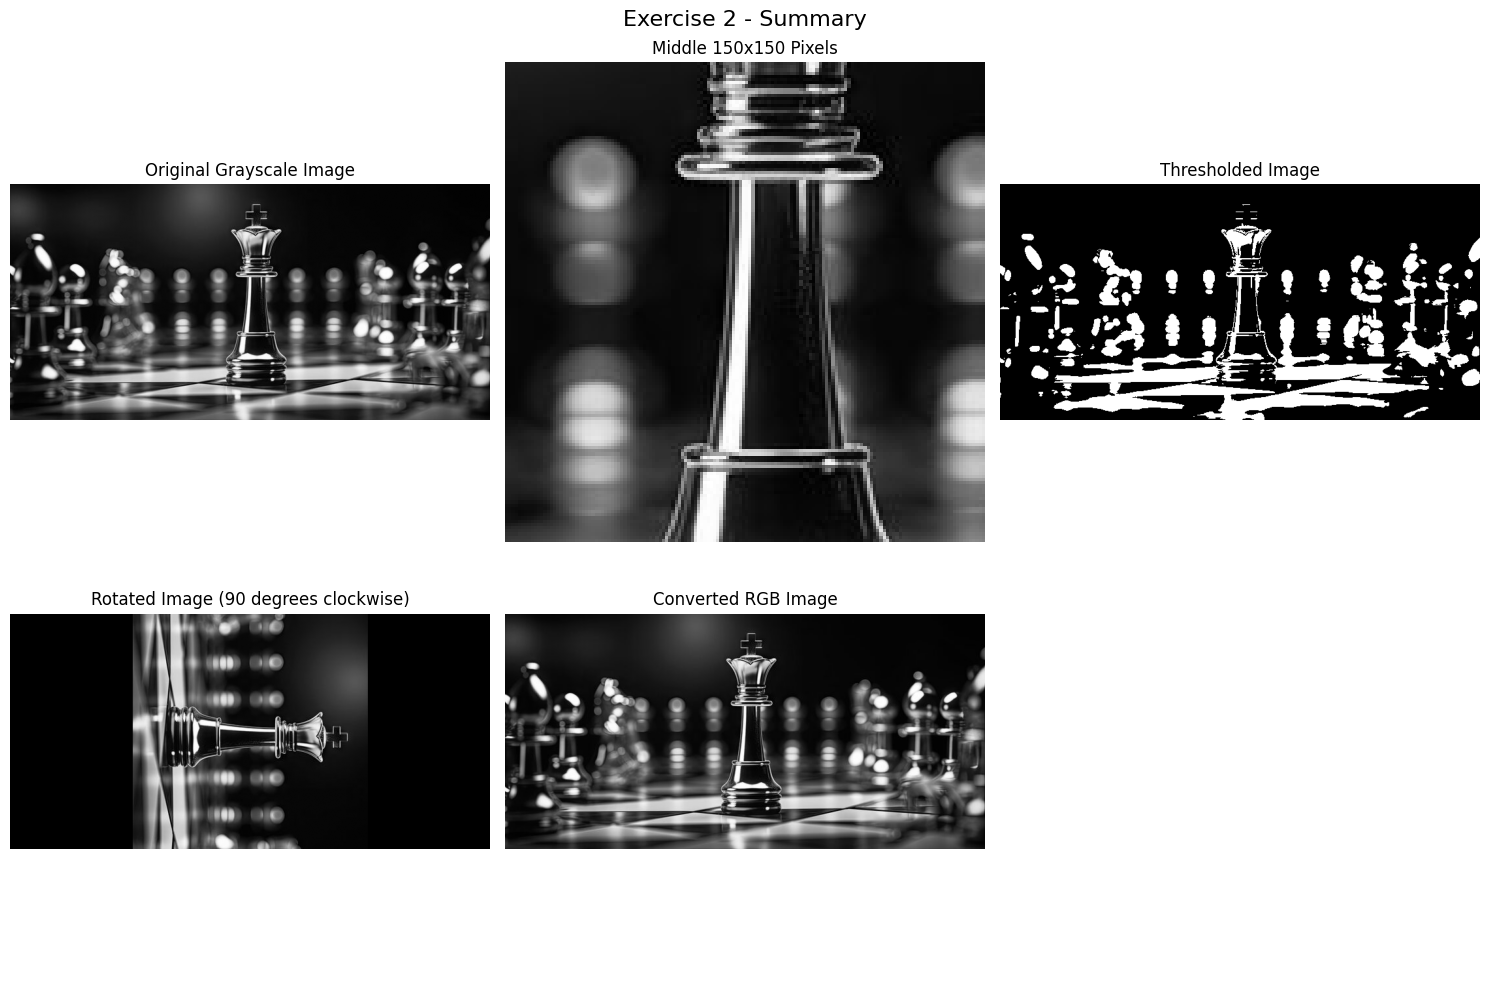

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(gray_img, cmap='gray')
axes[0, 0].set_title('Original Grayscale Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(middle_section, cmap='gray')
axes[0, 1].set_title('Middle 150x150 Pixels')
axes[0, 1].axis('off')

axes[0, 2].imshow(thresholded, cmap='gray')
axes[0, 2].set_title('Thresholded Image')
axes[0, 2].axis('off')

axes[1, 0].imshow(rotated_img, cmap='gray')
axes[1, 0].set_title('Rotated Image (90 degrees clockwise)')
axes[1, 0].axis('off')

axes[1, 1].imshow(rgb_from_gray)
axes[1, 1].set_title('Converted RGB Image')
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.suptitle('Exercise 2 - Summary', fontsize=16)
plt.tight_layout()
plt.show()


---
# Exercise 3 - Image Compression using PCA (from Scratch)

**What is PCA?**
PCA finds the most important 'directions' in data. For images, we can keep only the top-k directions (principal components) and still reconstruct a good version - this is compression!

**Steps:** Load → Centre → Covariance Matrix → Eigendecomposition → Sort → Reconstruct → Compare

### Step 1: Load Image and Convert to Grayscale

Image shape: (360, 735)


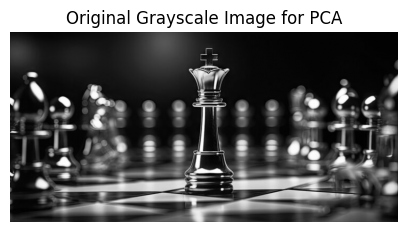

In [18]:
pca_img_pil = Image.open('/content/drive/MyDrive/AI and Machine Learning/Image.jpg').convert('L')
pca_img = np.array(pca_img_pil, dtype=np.float64)

print('Image shape:', pca_img.shape)

plt.figure(figsize=(5, 5))
plt.imshow(pca_img, cmap='gray')
plt.title('Original Grayscale Image for PCA')
plt.axis('off')
plt.show()


### Step 2: Centre the Data (Standardise)

In [19]:
mean = np.mean(pca_img, axis=0)

centered = pca_img - mean

print('Mean shape:', mean.shape)
print('Centered data shape:', centered.shape)
print('Mean of centered data (should be close to 0):', np.mean(centered).round(8))


Mean shape: (735,)
Centered data shape: (360, 735)
Mean of centered data (should be close to 0): -0.0


### Step 3: Compute the Covariance Matrix

In [20]:
n = centered.shape[0]

cov_matrix = (1 / (n - 1)) * np.dot(centered.T, centered)

print('Covariance matrix shape:', cov_matrix.shape)
print('This symmetric matrix captures all feature relationships.')


Covariance matrix shape: (735, 735)
This symmetric matrix captures all feature relationships.


### Step 4: Compute Eigenvalues and Eigenvectors

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print('Number of eigenvalues:', len(eigenvalues))
print('Top 5 eigenvalues:', eigenvalues[:5].round(2))


Number of eigenvalues: 735
Top 5 eigenvalues: [930783.56 332868.1  200611.62 162763.92 132140.26]


### Step 5: Identify Principal Components - Cumulative Variance Plot

90% variance explained by 17 components
95% variance explained by 27 components
99% variance explained by 61 components


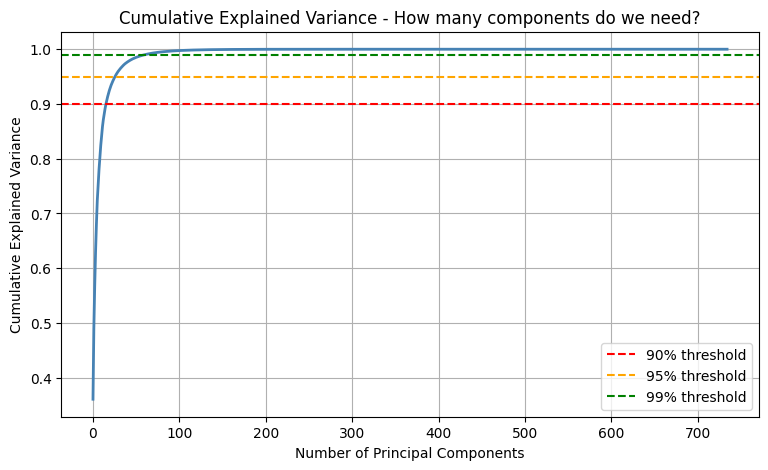

In [22]:
total_variance = np.sum(eigenvalues)
explained_variance = eigenvalues / total_variance

cumulative_variance = np.cumsum(explained_variance)

for threshold in [0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f'{int(threshold*100)}% variance explained by {k} components')

plt.figure(figsize=(9, 5))
plt.plot(cumulative_variance, color='steelblue', linewidth=2)
plt.axhline(y=0.90, color='red',    linestyle='--', label='90% threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.axhline(y=0.99, color='green',  linestyle='--', label='99% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance - How many components do we need?')
plt.legend()
plt.grid(True)
plt.show()


### Step 6: Define Reconstruction Function

In [23]:
def reconstruct_image(centered_data, eigenvectors, mean, k):
    """
    Compress and then reconstruct an image using k principal components.

    Step 1 - Compress:   Project data onto top-k eigenvectors (reduces dimensions)
    Step 2 - Decompress: Project back to original space
    Step 3 - Un-center:  Add the mean back
    """
    top_k = eigenvectors[:, :k]

    compressed = np.dot(centered_data, top_k)

    reconstructed = np.dot(compressed, top_k.T)

    reconstructed = reconstructed + mean

    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed

print('Reconstruction function defined!')


Reconstruction function defined!


### Step 7: Experiment - Compare Four Different k Values

In [24]:
k_values = [10, 20, 50, 100]

reconstructed_images = {}

for k in k_values:
    rec = reconstruct_image(centered, eigenvectors, mean, k)
    var_pct = cumulative_variance[k - 1] * 100
    reconstructed_images[k] = (rec, var_pct)
    print(f'k = {k:4d}  →  {var_pct:.2f}% variance explained')


k =   10  →  82.43% variance explained
k =   20  →  92.50% variance explained
k =   50  →  98.45% variance explained
k =  100  →  99.75% variance explained


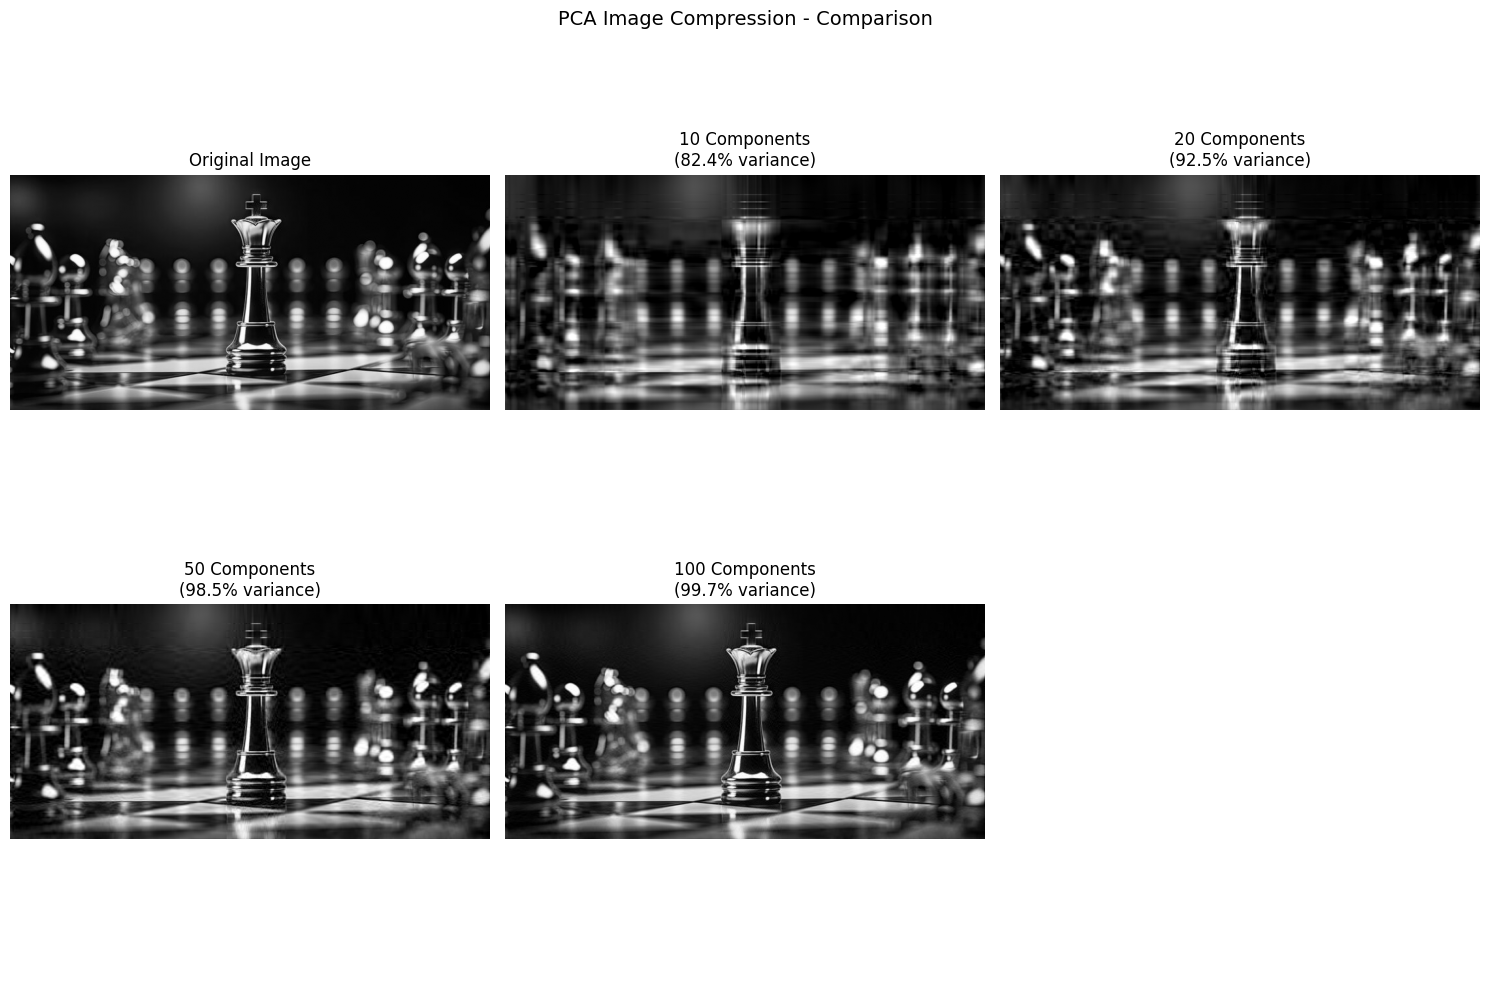

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(pca_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

positions = [(0,1), (0,2), (1,0), (1,1)]
for (r, c), k in zip(positions, k_values):
    rec_img, var = reconstructed_images[k]
    axes[r, c].imshow(rec_img, cmap='gray')
    axes[r, c].set_title(f'{k} Components\n({var:.1f}% variance)')
    axes[r, c].axis('off')

axes[1, 2].axis('off')

plt.suptitle('PCA Image Compression - Comparison', fontsize=14)
plt.tight_layout()
plt.show()


### Evaluate: MSE (Mean Squared Error) for Each k

k (components) | Variance %  | MSE (error)
---------------------------------------------
            10 |      82.43% |      601.24
            20 |      92.50% |      253.59
            50 |      98.45% |       52.77
           100 |      99.75% |        8.76


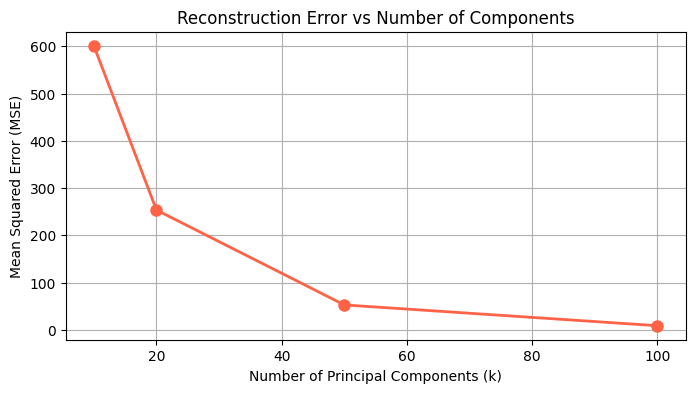

Conclusion: More components = lower error = better image quality (less compression).


In [26]:
print('k (components) | Variance %  | MSE (error)')
print('-' * 45)

mse_values = []
for k in k_values:
    rec_img, var = reconstructed_images[k]
    mse = np.mean((pca_img - rec_img) ** 2)
    mse_values.append(mse)
    print(f'{k:>14} | {var:>10.2f}% | {mse:>11.2f}')

plt.figure(figsize=(8, 4))
plt.plot(k_values, mse_values, marker='o', color='tomato', linewidth=2, markersize=8)
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Reconstruction Error vs Number of Components')
plt.grid(True)
plt.show()

print('Conclusion: More components = lower error = better image quality (less compression).')
